# Tutorial spatial

**This tutorial is for running NS-Forest for spatial transcriptomic gene panel design.**

The first step is filtering non-zero median expression of all genes represented in the AnnData object. This is done by taking the expression values for each gene for all cells, removing the zero values, and calculating the median per gene. Median is used instead of mean because mean is sensitive to outliers and skewed with noise. We can visualize these genes' non-zero median expression in a histogram and plot the 10th and 99th percentiles. We remove genes with relatively low or high expression. High expression can effect the spatial imaging results due to "optical crowding", resulting from excessive fluorescent signal from high transcript dense regions (https://www.nature.com/articles/s41467-021-27798-0). 

The next step is filtering by transcript length. In spatial transcriptomics, probes are designed to target each gene; genes with more probes tend to have higher sensitivity to be detected (https://pmc.ncbi.nlm.nih.gov/articles/PMC10054990/). The minimum transcript length is to ensure high detection. The transcript lengths are from Gencode's BioMart. Due to multiple transcript lengths associated with a single gene, the longest length is chosen. The NS-Forest package contains the gencode files for human (v47) and mouse (vM36), which can be found in the `gencode_annotation` folder. The default minimum transcript length is 700. This value is adjustable depending on the organ and species. For example, when looking at a mouse brain dataset, we chose 700 to include Sst (721bp), which is a well known neuronal inhibitory marker gene.

**Note**: adata.var.index should be unique. It is recommended that the adata.var_names be the ensembl_id, but gene_symbol should work. 

After running spaceTx_genefilter, the standard NS-Forest pipeline is run, including prep_medians, prep_binary_score, and nsforesting.NSForest. This pipeline outputs a set of 1-6 markers per cell type that can be used for spatial transcriptomic gene panel.

### Setting up environment

In [1]:
import pandas as pd
import scanpy as sc
import nsforest as ns
from nsforest import utils

In [2]:
# %cd /path/to/NSForest_v4.2
data_folder = "demo_data/"
cluster_header = "cluster"
output_folder = "demo_outputs/"
file = data_folder + "adata_layer1.h5ad"
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 871 × 16497
    obs: 'cluster'
    layers: None

### Filtering genes to optimize spatial gene panels. 

Non-zero median expression percentile limits: 
0.10    1.584962
0.99    8.898539
dtype: float64


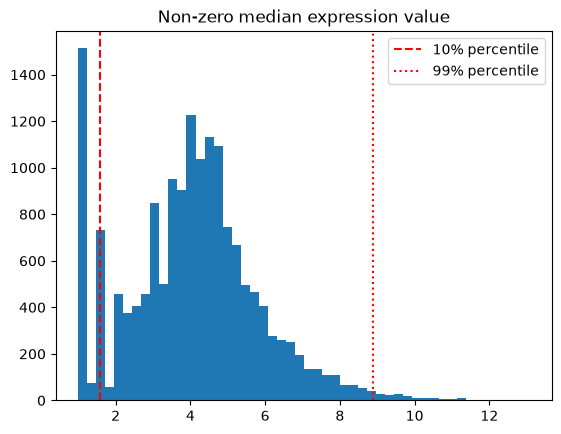

FILTER 1: 13944 out of 16497 total genes passed the expression filter (lower_percentile = 0.1, upper_percentile = 0.99).

FILTER 2: 14278 out of 16497 total genes passed the transcript length filter (min_txLength = 700).

FINAL SELECTION: 12147 out of 16497 total genes passed both filters.


AnnData object with n_obs × n_vars = 871 × 12147
    obs: 'cluster'
    layers: None

In [3]:
adata = ns.pp.spaceTx_genefilter(adata, gencode_folder = "gencode_annotation")
adata

### Calculating medians and binary scores per cluster

In [4]:
adata = ns.pp.prep_medians(adata, cluster_header)
adata = ns.pp.prep_binary_scores(adata, cluster_header)

Calculating medians per cluster: 100%|██████████| 16/16 [00:00<00:00, 17.44it/s]


Saving medians as adata.varm.medians_cluster
median: 0.0
mean: 1.841
std: 2.523
Only positive genes selected. 9434 positive genes out of 12147 total genes
--- 0.9969689846038818 seconds ---


Calculating binary scores per cluster: 100%|██████████| 16/16 [00:41<00:00,  2.59s/it]

Saving binary scores as adata.varm.binary_scores_cluster
median: 0.119
mean: 0.208
std: 0.251
--- 41.60901188850403 seconds ---


### Running NS-Forest

In [5]:
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Running NS-Forest version 4.2

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.709
	Average number of genes after gene_selection in each cluster: 578.5625
Saving number of genes selected per cluster as...
demo_outputs/cluster_gene_selection.csv
--- 0.0251314640045166 seconds ---

Number of clusters to evaluate: 16
1 out of 16:
	e1_e299_SLC17A7_L5b_Cdh13
	Pre-selected 1128 genes to feed into Random Forest.
	NSForest-selected markers: ['LINC00507']
	fbeta: 0.96
	precision: 0.978
	recall: 0.893
2 out of 16:
	g1_g48_GLI3_Astro_Gja1
	Pre-selected 444 genes to feed into Random Forest.
	NSForest-selected markers: ['LINC00498']
	fbeta: 0.95
	precision: 1.0
	recall: 0.792
3 out of 16:
	g2_g27_APBB1IP_Micro_Ctss
	Pre-selected 284 genes to feed into Random Forest.
	NSForest-selected markers: ['SYK']
	fbeta: 0.922
	precision: 1.0
	recall: 0.704
4 out of 16:
	g3_g18_GPNMB_OPC_Pdgfra
	Pre-selected 251 genes to feed into Random Forest.


Calculating medians per cluster: 100%|██████████| 16/16 [00:00<00:00, 331.98it/s]

Saving supplementary table as...
demo_outputs/cluster_markers_onTarget_supp.csv
Saving supplementary table as...
demo_outputs/cluster_markers_onTarget.csv

Saving final results table as...
demo_outputs/cluster_results.csv
Saving final results table as...
demo_outputs/cluster_results.pkl


In [6]:
results

,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.2,cluster,e1_e299_SLC17A7_L5b_Cdh13,299,0.959741,0.978022,0.892977,566,6,32,267,1,[LINC00507],"[SLC17A7, LINC00508, TBR1, ANKRD33B, NPTX1, LI...",0.792614
1,4.2,cluster,g1_g48_GLI3_Astro_Gja1,48,0.950000,1.000000,0.791667,823,0,10,38,1,[LINC00498],"[SLC25A18, LINC00498, FGFR3, EMX2OS, PAPLN, SL...",1.000000
2,4.2,cluster,g2_g27_APBB1IP_Micro_Ctss,27,0.922330,1.000000,0.703704,844,0,8,19,1,[SYK],"[CSF2RA, SYK, MS4A7, IKZF1, FGD2, CX3CR1, C1QC...",1.000000
3,4.2,cluster,g3_g18_GPNMB_OPC_Pdgfra,18,0.833333,1.000000,0.500000,853,0,9,9,1,[COL20A1],"[COL20A1, STK32A, OLIG2, KLRC2, CSPG4, B3GNT7,...",1.000000
4,4.2,cluster,g4_g9_MOG_Oligo_Opalin,9,0.975610,1.000000,0.888889,862,0,1,8,1,[CNDP1],"[MOBP, CD22, CNDP1, TF, ASPA, PPP1R14A, CLMN, ...",1.000000
5,4.2,cluster,i10_i16_TSPAN12_Vip_Mybpc1,16,0.803571,0.900000,0.562500,854,1,7,9,2,"[TSPAN12, CHRNB3]","[TSPAN12, LINC01539, TMC5, CHRNB3, ANGPT1, DCN...",0.783762
6,4.2,cluster,i11_i6_EGF_Vip_Mybpc1,6,0.555556,0.666667,0.333333,864,1,4,2,1,[FZD8],"[EGF, FZD8, BRAT1, RHPN1, SLC47A2, GOLGA2P8, L...",1.000000
7,4.2,cluster,i1_i90_COL5A2_Ndnf_Car4,90,0.845324,1.000000,0.522222,781,0,43,47,2,"[COL5A2, TRPC3]","[NMBR, BMP2, COL5A2, ADRA1D, TRPC3, PAPSS2, BM...",0.618906
8,4.2,cluster,i2_i77_LHX6_Sst_Cbln4,77,0.857143,1.000000,0.545455,794,0,35,42,2,"[LHX6, GRIK3]","[LHX6, CALB1, TAC1, RSPO3, TRBC2, GRIK3, RNF15...",0.942058
9,4.2,cluster,i3_i56_BAGE2_Ndnf_Cxcl14,56,0.641892,0.826087,0.339286,811,4,37,19,2,"[SCN5A, GREM2]","[SCN5A, ST8SIA2, GREM2, SYT10, ARHGAP18, ZNF42...",0.531211
